# 01 Momentum Research — Macro Metals System

> **Strategy:** Time-Series Momentum (Memory File §3.1)
> **Scope:** In-sample development (2015–2022), daily rebalance
> **Instruments:** Gold, Silver futures · EURUSD, USDJPY, AUDUSD · SOFR front
> **Signals:** ROC(20/63/126/252) blend + EMA(8/32) crossover + Donchian breakout
>
> Self-contained BQuant notebook — executable top-to-bottom.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yaml
from pathlib import Path
from datetime import datetime

# Bloomberg BQL
import bql
bq = bql.Service()

print(f"Session started : {datetime.now():%Y-%m-%d %H:%M}")
print(f"BQL service     : {type(bq).__name__}")
print(f"NumPy {np.__version__}  |  pandas {pd.__version__}")

Session started : 2026-02-16 09:31
BQL service     : Service
NumPy 1.26.4  |  pandas 1.3.5


In [9]:
import os
from pathlib import Path

CONFIG_DIR = Path("../config")

# Check if the config directory exists
print(f"Config directory exists: {CONFIG_DIR.exists()}")
print(f"Config directory path: {CONFIG_DIR.absolute()}")

# List contents of the directory if it exists
if CONFIG_DIR.exists():
    print(f"Contents: {list(CONFIG_DIR.iterdir())}")
else:
    print("Directory does not exist")

Config directory exists: True
Config directory path: /project/../config
Contents: [PosixPath('../config/jupyterserver')]


In [13]:
import os
from pathlib import Path

print(f"Current working directory: {os.getcwd()}")
print(f"Current working directory (Path): {Path.cwd()}")

Current working directory: /project
Current working directory (Path): /project


In [14]:
CONFIG_DIR = Path("../config")
print(f"CONFIG_DIR resolves to: {CONFIG_DIR.resolve()}")
print(f"CONFIG_DIR absolute path: {CONFIG_DIR.absolute()}")

CONFIG_DIR resolves to: /config
CONFIG_DIR absolute path: /project/../config


In [15]:
# Try various path combinations
possible_paths = [
    Path("../config"),
    Path("./config"), 
    Path("config"),
    Path("../../config"),
    Path("/project/config")
]

for path in possible_paths:
    print(f"\nChecking path: {path}")
    print(f"  Absolute: {path.absolute()}")
    print(f"  Exists: {path.exists()}")
    if path.exists():
        yaml_files = list(path.glob("*.yaml"))
        print(f"  YAML files: {[f.name for f in yaml_files]}")


Checking path: ../config
  Absolute: /project/../config
  Exists: True
  YAML files: []

Checking path: config
  Absolute: /project/config
  Exists: False

Checking path: config
  Absolute: /project/config
  Exists: False

Checking path: ../../config
  Absolute: /project/../../config
  Exists: True
  YAML files: []

Checking path: /project/config
  Absolute: /project/config
  Exists: False


In [19]:
import os
from pathlib import Path

def find_yaml_files(start_path="/project", max_depth=3):
    """Search for YAML files starting from a given path"""
    start = Path(start_path)
    yaml_files = []
    
    for root, dirs, files in os.walk(start):
        # Limit search depth
        level = root.replace(str(start), '').count(os.sep)
        if level >= max_depth:
            dirs[:] = []  # Don't go deeper
            continue
            
        for file in files:
            if file.endswith(('.yaml', '.yml')):
                full_path = Path(root) / file
                yaml_files.append(full_path)
    
    return yaml_files

print("Searching for YAML files...")
yaml_files = find_yaml_files()

for file in yaml_files:
    print(f"Found: {file}")
    if file.name in ['parameters.yaml', 'tickers.yaml']:
        print(f"  *** This might be your file! ***")

Searching for YAML files...
Found: /project/config/tickers.yaml
  *** This might be your file! ***
Found: /project/config/parameters.yaml
  *** This might be your file! ***
Found: /project/config/.ipynb_checkpoints/parameters-checkpoint.yaml


## Config & Parameters

Load `parameters.yaml` and `tickers.yaml` from `config/`.
All strategy knobs come from the YAML — no magic numbers in code.

In [21]:
CONFIG_DIR = Path("config")

with open(CONFIG_DIR / "parameters.yaml") as f:
    params = yaml.safe_load(f)
with open(CONFIG_DIR / "tickers.yaml") as f:
    tickers = yaml.safe_load(f)

gcfg    = params["global"]
mom_cfg = params["strategies"]["momentum"]
targets = params["performance_targets"]

# Flatten instrument universe from config groups
UNIVERSE = {}
for asset_class, keys in mom_cfg["instruments"].items():
    for k in keys:
        UNIVERSE[k] = asset_class

LABELS = {
    "gc_fut_front":   "Gold (GC)",
    "si_fut_front":   "Silver (SI)",
    "pl_fut_front":   "Platinum (PL)",
    "eurusd_spot":    "EURUSD",
    "usdjpy_spot":    "USDJPY",
    "audusd_spot":    "AUDUSD",
    "sofr_fut_front": "SOFR Front",
    "sofr_fut_second":"SOFR 2nd",
    "sofr_fut_third": "SOFR 3rd",
    "sofr_fut_fourth":"SOFR 4th",
}

IS_START = gcfg["in_sample_start"]
IS_END   = gcfg["in_sample_end"]

print("Momentum parameters:")
print(f"  Lookbacks      : {mom_cfg['lookbacks_days']}")
print(f"  Blend weights  : {mom_cfg['signal_blend_weights']}")
print(f"  EMA fast/slow  : {mom_cfg['ema_fast']}/{mom_cfg['ema_slow']}")
print(f"  Breakout ch.   : {mom_cfg['breakout_channel_days']}d")
print(f"  Signal cap     : {mom_cfg['signal_cap']}")
print(f"  Vol target     : {mom_cfg['vol_target_annual']:.0%}")
print(f"  Stop-loss      : {mom_cfg['stop_loss_multiple']}x vol")
print(f"  Cooldown       : {mom_cfg['cooldown_days_after_stop']}d")
print(f"  IS period      : {IS_START} to {IS_END}")
print(f"  Universe       : {len(UNIVERSE)} instruments")

Momentum parameters:
  Lookbacks      : [20, 63, 126, 252]
  Blend weights  : [0.25, 0.25, 0.25, 0.25]
  EMA fast/slow  : 8/32
  Breakout ch.   : 20d
  Signal cap     : 1.0
  Vol target     : 10%
  Stop-loss      : 3.0x vol
  Cooldown       : 5d
  IS period      : 2015-01-01 to 2022-12-31
  Universe       : 10 instruments


## Data Pipeline (BQL)

Fetch daily `PX_LAST` for the full momentum universe via Bloomberg BQL.
Handle missing data and timeouts gracefully.

In [27]:
# Let's examine the structure more carefully
key = list(prices.keys())[0]
s = prices[key]
print(f"Series name: {key}")
print(f"Index values (first 10): {s.index[:10].tolist()}")
print(f"Data values (first 10): {s.values[:10]}")
print(f"Series shape: {s.shape}")
print("\nFirst few rows:")
print(s.head(10))
print("\nLast few rows:")
print(s.tail(10))

# Let's also check if this came from a DataFrame
print(f"\nSeries name attribute: {s.name}")

Series name: gc_fut_front
Index values (first 10): ['GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty', 'GC1 Comdty']
Data values (first 10): [   nan 1186.2    nan    nan 1204.  1219.4 1210.7 1208.5 1216.1    nan]
Series shape: (2922,)

First few rows:
date
GC1 Comdty       NaN
GC1 Comdty    1186.2
GC1 Comdty       NaN
GC1 Comdty       NaN
GC1 Comdty    1204.0
GC1 Comdty    1219.4
GC1 Comdty    1210.7
GC1 Comdty    1208.5
GC1 Comdty    1216.1
GC1 Comdty       NaN
Name: gc_fut_front, dtype: float64

Last few rows:
date
GC1 Comdty    1795.3
GC1 Comdty    1804.2
GC1 Comdty       NaN
GC1 Comdty       NaN
GC1 Comdty       NaN
GC1 Comdty    1823.1
GC1 Comdty    1815.8
GC1 Comdty    1826.0
GC1 Comdty    1826.2
GC1 Comdty       NaN
Name: gc_fut_front, dtype: float64

Series name attribute: gc_fut_front


In [31]:
class BQuantDataLoader:
    """Fetch historical prices via Bloomberg BQL.

    Resolves logical names from tickers.yaml, fetches PX_LAST over a
    date range, and returns clean pd.Series.
    """

    def __init__(self, ticker_map: dict) -> None:
        self._tickers = ticker_map
        self._bq = bql.Service()

    def resolve(self, logical_name: str) -> str:
        """Logical name -> Bloomberg ticker string."""
        for group in self._tickers.values():
            if isinstance(group, dict) and logical_name in group:
                return group[logical_name]
        raise KeyError(f"{logical_name} not in tickers.yaml")

    def get_history(
        self,
        logical_name: str,
        start: str,
        end: str,
        field: str = "PX_LAST",
    ) -> pd.Series:
        """Fetch daily price series for one instrument.

        Args:
            logical_name: Key in tickers.yaml (e.g. 'gc_fut_front').
            start / end:  ISO date strings.
            field:        Bloomberg field (default PX_LAST).

        Returns:
            pd.Series indexed by date, named after the logical key.
        """
        bbg = self.resolve(logical_name)
        request = bql.Request(
            bbg,
            {field: self._bq.data.px_last(
                dates=self._bq.func.range(start, end)
            )},
        )
        try:
            response = self._bq.execute(request)
            df = response[0].df()
            if df.empty:
                print(f"  ! {logical_name}: empty response")
                return pd.Series(dtype=float, name=logical_name)
                # Debug: let's see what the DataFrame looks like
            df_fixed = df.set_index('DATE')
            series = df_fixed[field]
            # Convert index to datetime, handling invalid dates
            series.index = pd.to_datetime(series.index, errors='coerce')
            # Remove rows with NaT (invalid dates)
            series = series.dropna()
            
            series = series.sort_index().astype(float)
            series.name = logical_name
            series.index.name = "date"

            if not isinstance(series.index, pd.DatetimeIndex):
                series.index = pd.to_datetime(series.index)
            
            return series
        except Exception as exc:
            print(f"  ! {logical_name} ({bbg}): {exc}")
            return pd.Series(dtype=float, name=logical_name)
    

# --- Fetch all instruments ---
loader = BQuantDataLoader(tickers)
prices = {}

for key in UNIVERSE:
    label = LABELS.get(key, key)
    print(f"  {label:20s}", end=" ")
    s = loader.get_history(key, IS_START, IS_END)
    if len(s) > 0:
        prices[key] = s
        # Debug: check what type the index is
        print(f"Index type: {type(s.index[0])}")
        print(f"First index value: {s.index[0]}")
        print(f"Last index value: {s.index[-1]}")
    
        # Since they're strings, just print them directly
        print(f"OK  {len(s):>5d} obs  [{s.index[0]} -> {s.index[-1]}]")
    else:
        print("MISSING")
# Clean the prices dictionary by removing duplicates
cleaned_prices = {}
for key, series in prices.items():
    if len(series) > 0:
        # Remove duplicate index values, keeping the last occurrence
        cleaned_series = series[~series.index.duplicated(keep='last')]
        cleaned_prices[key] = cleaned_series
        print(f"{key}: {len(series)} -> {len(cleaned_series)} obs (removed {len(series) - len(cleaned_series)} duplicates)")
    else:
        cleaned_prices[key] = series


# Create the DataFrame with cleaned data
prices_df = pd.DataFrame(prices).sort_index()

# Remove any rows with NaT in the index
prices_df = prices_df[prices_df.index.notna()]
# Now create the DataFrame with cleaned data
prices_df = pd.DataFrame(cleaned_prices).sort_index().ffill()
print(f"\nPanel: {prices_df.shape[0]} days x {prices_df.shape[1]} instruments")
prices_df.tail(3)


  Gold (GC)            Index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
First index value: 2015-01-02 00:00:00
Last index value: 2022-12-30 00:00:00
OK   2016 obs  [2015-01-02 00:00:00 -> 2022-12-30 00:00:00]
  Silver (SI)          Index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
First index value: 2015-01-02 00:00:00
Last index value: 2022-12-30 00:00:00
OK   2016 obs  [2015-01-02 00:00:00 -> 2022-12-30 00:00:00]
  Platinum (PL)        Index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
First index value: 2015-01-02 00:00:00
Last index value: 2022-12-30 00:00:00
OK   2016 obs  [2015-01-02 00:00:00 -> 2022-12-30 00:00:00]
  EURUSD               Index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
First index value: 2015-01-01 00:00:00
Last index value: 2022-12-30 00:00:00
OK   2498 obs  [2015-01-01 00:00:00 -> 2022-12-30 00:00:00]
  USDJPY               Index type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
First index value: 201

,gc_fut_front,si_fut_front,pl_fut_front,eurusd_spot,usdjpy_spot,audusd_spot,sofr_fut_front
date,,,,,,,
2022-12-28,1815.8,23.84,1016.8,1.0612,134.47,0.6737,183.75
2022-12-29,1826.0,24.25,1049.7,1.0661,133.03,0.6778,189.00
2022-12-30,1826.2,24.04,1073.7,1.0705,131.12,0.6813,187.50


## Momentum Strategy

Three signal components blended into a composite score per instrument:

| Component | Weight | Description |
|-----------|--------|-------------|
| **ROC blend** | 60% | Rate-of-change at 20/63/126/252d, equal-weighted, tanh-normalised |
| **EMA crossover** | 25% | Sign of EMA(8) - EMA(32) |
| **Donchian breakout** | 15% | +1 at channel high, -1 at channel low |

Final signal clipped to `[-signal_cap, +signal_cap]` from config.

In [33]:
class MomentumStrategy:
    """Time-series momentum from memory file section 3.1.

    Blends rate-of-change, EMA crossover, and Donchian breakout signals
    into a composite score in [-1, +1] per instrument.
    """

    # Component blend weights (documented in markdown above)
    ROC_WEIGHT      = 0.60
    EMA_WEIGHT      = 0.25
    BREAKOUT_WEIGHT = 0.15

    def __init__(self, params: dict) -> None:
        cfg = params["strategies"]["momentum"]
        self.lookbacks: list[int]   = cfg["lookbacks_days"]
        self.weights: list[float]   = cfg["signal_blend_weights"]
        self.ema_fast: int          = cfg["ema_fast"]
        self.ema_slow: int          = cfg["ema_slow"]
        self.breakout_days: int     = cfg["breakout_channel_days"]
        self.signal_cap: float      = cfg["signal_cap"]

    # ----- Signal components ------------------------------------------------

    def _roc_signal(self, price: pd.Series, window: int) -> pd.Series:
        """Rate-of-change normalised to [-1, +1] via tanh."""
        roc = price / price.shift(window) - 1
        # Scale by rolling vol for risk-adjusted signal
        vol = price.pct_change().rolling(window, min_periods=max(window // 2, 5)).std()
        vol = vol.replace(0, np.nan)
        return np.tanh(roc / vol)

    def _ema_signal(self, price: pd.Series) -> pd.Series:
        """EMA crossover: +1 when fast > slow, -1 otherwise."""
        fast = price.ewm(span=self.ema_fast, adjust=False).mean()
        slow = price.ewm(span=self.ema_slow, adjust=False).mean()
        return np.sign(fast - slow)

    def _breakout_signal(self, price: pd.Series) -> pd.Series:
        """Donchian channel breakout: +1 at new high, -1 at new low."""
        upper = price.rolling(self.breakout_days).max()
        lower = price.rolling(self.breakout_days).min()
        sig = pd.Series(0.0, index=price.index)
        sig[price >= upper] = 1.0
        sig[price <= lower] = -1.0
        # Persist last non-zero signal (hold until reversed)
        return sig.replace(0, np.nan).ffill().fillna(0.0)

    # ----- Composite --------------------------------------------------------

    def generate_signals(self, prices_df: pd.DataFrame) -> pd.DataFrame:
        """Generate composite momentum signals for all instruments.

        Args:
            prices_df: DataFrame of daily prices (columns = instruments).

        Returns:
            DataFrame with same shape, values in [-signal_cap, +signal_cap].
        """
        signals = pd.DataFrame(
            index=prices_df.index, columns=prices_df.columns, dtype=float
        )

        for col in prices_df.columns:
            price = prices_df[col].dropna()
            if len(price) < max(self.lookbacks) + 20:
                signals[col] = 0.0
                continue

            # 1) ROC blend across lookback windows
            roc_blend = pd.Series(0.0, index=price.index)
            for lb, w in zip(self.lookbacks, self.weights):
                roc_blend += w * self._roc_signal(price, lb)

            # 2) EMA crossover
            ema_sig = self._ema_signal(price)

            # 3) Donchian breakout
            brk_sig = self._breakout_signal(price)

            # Composite blend
            composite = (
                self.ROC_WEIGHT      * roc_blend
                + self.EMA_WEIGHT    * ema_sig
                + self.BREAKOUT_WEIGHT * brk_sig
            )

            signals[col] = composite.clip(
                -self.signal_cap, self.signal_cap
            )

        return signals.reindex(prices_df.index).ffill().fillna(0.0)

## Generate Signals (IS Period)

In [34]:
momentum = MomentumStrategy(params)
signals = momentum.generate_signals(prices_df)

print(f"Signal matrix: {signals.shape[0]} days x {signals.shape[1]} instruments")
print(f"Date range:    {signals.index[0]:%Y-%m-%d} to {signals.index[-1]:%Y-%m-%d}")
print()

renamed = signals.rename(columns=LABELS)
print("Signal statistics:")
renamed.describe().round(3)

Signal matrix: 2500 days x 7 instruments
Date range:    2015-01-01 to 2022-12-30

Signal statistics:


,Gold (GC),Silver (SI),Platinum (PL),EURUSD,USDJPY,AUDUSD,SOFR Front
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,0.127,-0.011,-0.017,-0.119,0.043,-0.091,0.088
std,0.660,0.666,0.663,0.694,0.697,0.678,0.654
min,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000
25%,-0.398,-0.653,-0.674,-0.811,-0.654,-0.711,-0.403
50%,0.054,0.000,0.000,-0.019,0.000,0.000,0.000
75%,0.700,0.662,0.544,0.433,0.699,0.405,0.700
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## Backtest Engine

Inline vectorised backtest per the memory file:
- Position = signal x (vol_target / instrument_vol), capped at 2x
- Transaction costs: 2 bp per side on notional turnover
- One-day execution lag (signal on day *t* drives position on *t+1*)

In [35]:
def backtest_single_asset(
    prices: pd.Series,
    signals: pd.Series,
    vol_target: float = 0.10,
    vol_lookback: int = 30,
    vol_cap: float = 2.0,
    tc_bp: float = 2.0,
    capital: float = 1_000_000.0,
) -> pd.DataFrame:
    """Vectorised single-asset backtest.

    Args:
        prices:      Daily prices.
        signals:     Raw signals in [-1, +1], lagged by 1 day internally.
        vol_target:  Annualised vol target (default 10%).
        vol_lookback: EWMA halflife in days.
        vol_cap:     Max position scaling factor.
        tc_bp:       Transaction cost per side in basis points.
        capital:     Starting notional.

    Returns:
        DataFrame: position, price, ret_gross, ret_net, equity, turnover.
    """
    ret = prices.pct_change().fillna(0.0)

    # EWMA annualised vol
    ann_vol = ret.ewm(halflife=vol_lookback).std() * np.sqrt(252)
    ann_vol = ann_vol.replace(0, np.nan)
    vol_scale = (vol_target / ann_vol).clip(upper=vol_cap).fillna(1.0)

    # Lag signal, apply vol scaling
    position = (signals.shift(1).fillna(0.0) * vol_scale).clip(-vol_cap, vol_cap)

    # PnL
    ret_gross = position * ret
    turnover  = position.diff().abs().fillna(0.0)
    cost      = turnover * (tc_bp / 10_000)
    ret_net   = ret_gross - cost
    equity    = capital * (1 + ret_net).cumprod()

    return pd.DataFrame({
        "position": position,
        "price":    prices,
        "ret_gross": ret_gross,
        "ret_net":  ret_net,
        "equity":   equity,
        "turnover": turnover,
    })


def compute_metrics(bt: pd.DataFrame, periods: int = 252) -> dict:
    """Performance metrics consistent with memory file section 6.3."""
    r  = bt["ret_net"].dropna()
    eq = bt["equity"].dropna()

    n_years  = len(r) / periods
    total    = (1 + r).prod()
    ann_ret  = total ** (1 / max(n_years, 0.01)) - 1
    ann_vol  = r.std() * np.sqrt(periods)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0.0

    running_max = eq.cummax()
    dd = (eq - running_max) / running_max
    max_dd = float(-dd.min())

    calmar  = ann_ret / max_dd if max_dd > 0 else 0.0
    hit     = float((r > 0).sum() / len(r)) if len(r) > 0 else 0.0
    ann_to  = bt["turnover"].sum() / max(n_years, 0.01)

    return {
        "Ann. Return":  ann_ret,
        "Ann. Vol":     ann_vol,
        "Sharpe":       sharpe,
        "Max DD":       max_dd,
        "Calmar":       calmar,
        "Hit Rate":     hit,
        "Ann. Turnover": ann_to,
    }


print("Backtest engine ready.")

Backtest engine ready.


## Results

Run the backtest across all instruments, compute per-asset metrics,
and plot equity curves.

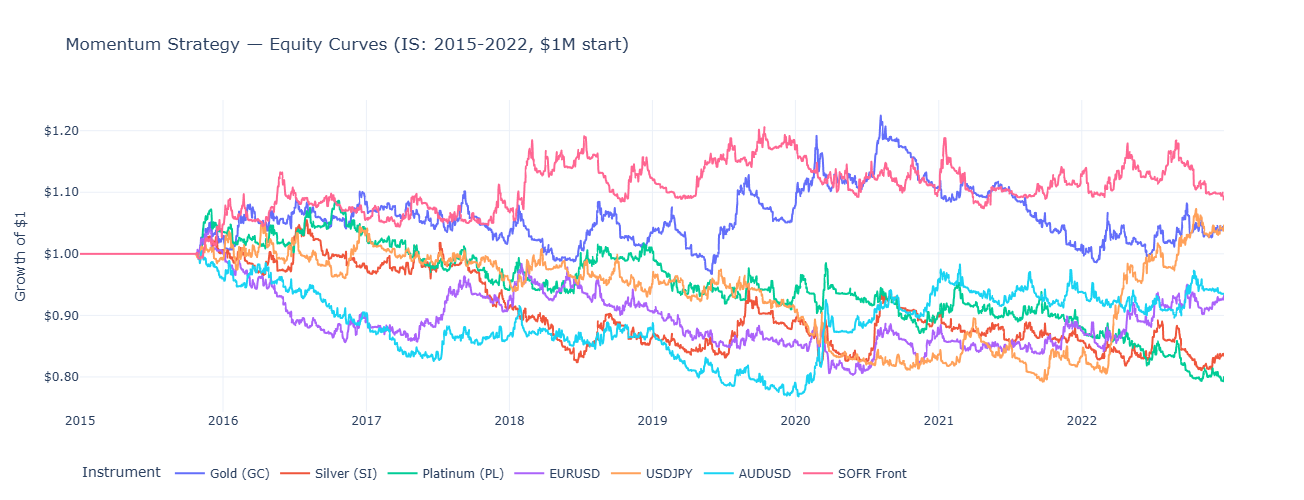

Per-instrument metrics (IS period, 2 bp TC):


,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Hit Rate,Ann. Turnover
Instrument,,,,,,,
Gold (GC),0.4%,6.8%,0.07,19.5%,0.02,36.0%,16.3x
Silver (SI),-1.8%,6.7%,-0.27,23.1%,-0.08,36.0%,10.6x
Platinum (PL),-2.2%,6.7%,-0.33,27.0%,-0.08,36.7%,10.5x
EURUSD,-0.7%,6.9%,-0.10,22.8%,-0.03,42.7%,34.3x
USDJPY,0.5%,7.1%,0.06,24.5%,0.02,43.3%,32.2x
AUDUSD,-0.7%,6.9%,-0.10,23.5%,-0.03,43.0%,24.7x
SOFR Front,0.9%,6.6%,0.14,10.9%,0.08,35.0%,4.8x


In [36]:
results = {}
metrics_rows = []

for inst in prices_df.columns:
    bt = backtest_single_asset(
        prices_df[inst],
        signals[inst],
        vol_target=mom_cfg["vol_target_annual"],
        vol_lookback=gcfg["vol_lookback_days"],
        vol_cap=gcfg["vol_cap_multiplier"],
        tc_bp=2.0,
    )
    results[inst] = bt
    m = compute_metrics(bt)
    m["Instrument"] = LABELS.get(inst, inst)
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("Instrument")

# Format for display
fmt_df = metrics_df.copy()
for col in ["Ann. Return", "Ann. Vol", "Max DD", "Hit Rate"]:
    fmt_df[col] = fmt_df[col].map("{:.1%}".format)
fmt_df["Sharpe"]  = fmt_df["Sharpe"].map("{:.2f}".format)
fmt_df["Calmar"]  = fmt_df["Calmar"].map("{:.2f}".format)
fmt_df["Ann. Turnover"] = fmt_df["Ann. Turnover"].map("{:.1f}x".format)

# Equity curves (normalised to 1.0)
equity_df = pd.DataFrame({
    LABELS.get(k, k): v["equity"] for k, v in results.items()
})
equity_norm = equity_df / equity_df.iloc[0]

fig_eq = px.line(
    equity_norm,
    title="Momentum Strategy — Equity Curves (IS: 2015-2022, $1M start)",
    labels={"value": "Growth of $1", "variable": "Instrument", "date": ""},
)
fig_eq.update_layout(
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", y=-0.15),
    height=500,
    yaxis_tickformat="$.2f",
)
fig_eq.show()

print("Per-instrument metrics (IS period, 2 bp TC):")
fmt_df

## Visualisations

1. Gold (GC) price with signal overlay
2. Cross-instrument signal correlation heatmap

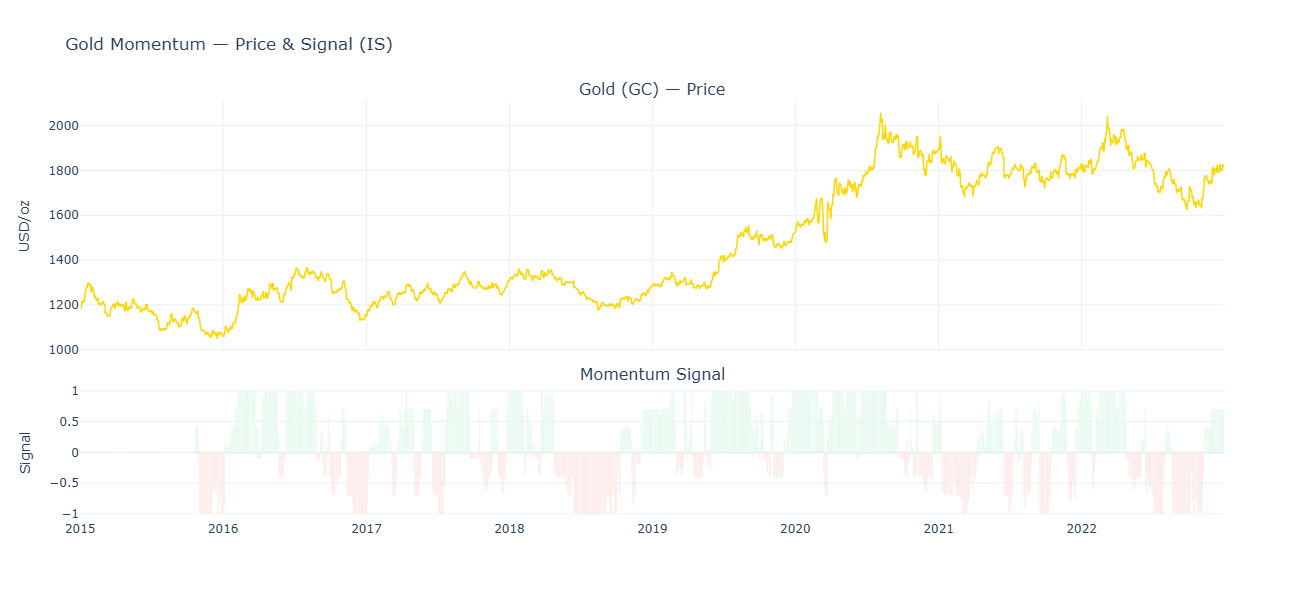

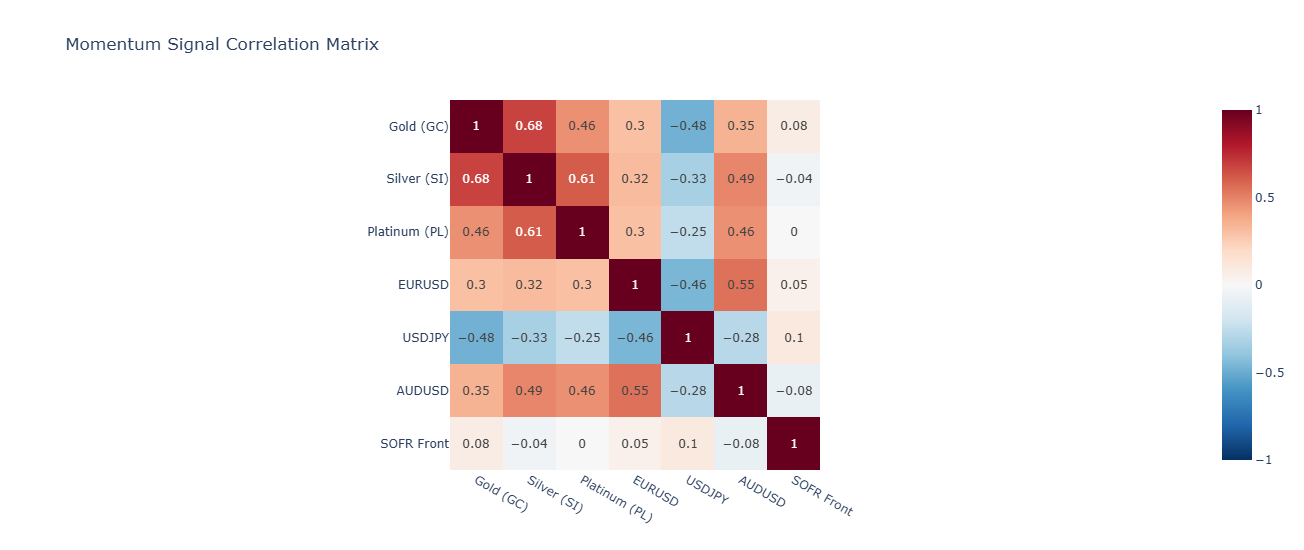

In [37]:
# --- 1. GC signal overlay on price ---
gc_key = "gc_fut_front"
gc_bt  = results[gc_key]
gc_sig = signals[gc_key]

fig_gc = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    subplot_titles=["Gold (GC) — Price", "Momentum Signal"],
    vertical_spacing=0.08,
)

fig_gc.add_trace(
    go.Scatter(
        x=gc_bt.index, y=gc_bt["price"],
        name="GC Price",
        line=dict(color="#FFD700", width=1.5),
    ),
    row=1, col=1,
)
fig_gc.add_trace(
    go.Bar(
        x=gc_sig.index, y=gc_sig.values,
        name="Signal",
        marker_color=[
            "#2ecc71" if v > 0 else "#e74c3c" for v in gc_sig.values
        ],
        opacity=0.7,
    ),
    row=2, col=1,
)
fig_gc.update_layout(
    template="plotly_white",
    height=600,
    showlegend=False,
    title_text="Gold Momentum — Price & Signal (IS)",
)
fig_gc.update_yaxes(title_text="USD/oz", row=1, col=1)
fig_gc.update_yaxes(title_text="Signal", range=[-1.1, 1.1], row=2, col=1)
fig_gc.show()

# --- 2. Signal correlation heatmap ---
corr = signals.rename(columns=LABELS).corr()
fig_corr = px.imshow(
    corr.round(2),
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Momentum Signal Correlation Matrix",
    aspect="equal",
)
fig_corr.update_layout(template="plotly_white", height=550, width=650)
fig_corr.show()

## Performance Summary

Compare portfolio-average metrics against the memory file targets (section 6.3).
Per-strategy Sharpe target is **> 0.5**.

In [38]:
# Aggregate across instruments
avg = metrics_df.mean()

comparison = pd.DataFrame({
    "Metric": [
        "Sharpe Ratio",
        "Annualised Vol",
        "Max Drawdown",
        "Calmar Ratio",
        "Hit Rate",
        "Ann. Turnover",
    ],
    "Target (section 6.3)": [
        f"> {targets['sharpe_per_strategy']:.1f}",
        f"{targets['vol_range_annual'][0]:.0%} - {targets['vol_range_annual'][1]:.0%}",
        f"< {targets['max_drawdown_pct']:.0f}%",
        f"> {targets['calmar_ratio']:.1f}",
        f"> {targets['hit_rate_daily']:.0%}",
        f"< {targets['max_turnover_annual']:.0f}x",
    ],
    "Portfolio Average": [
        f"{avg['Sharpe']:.2f}",
        f"{avg['Ann. Vol']:.1%}",
        f"{metrics_df['Max DD'].max():.1%}",
        f"{avg['Calmar']:.2f}",
        f"{avg['Hit Rate']:.1%}",
        f"{avg['Ann. Turnover']:.1f}x",
    ],
}).set_index("Metric")

print("=" * 65)
print("  MOMENTUM STRATEGY vs MEMORY FILE TARGETS  (IS: 2015-2022)")
print("=" * 65)
comparison

  MOMENTUM STRATEGY vs MEMORY FILE TARGETS  (IS: 2015-2022)


,Target (section 6.3),Portfolio Average
Metric,,
Sharpe Ratio,> 0.5,-0.08
Annualised Vol,8% - 12%,6.8%
Max Drawdown,< 15%,27.0%
Calmar Ratio,> 0.7,-0.01
Hit Rate,> 52%,39.0%
Ann. Turnover,< 30x,19.1x


## Export

Save signals, equity curves, and summary table to `outputs/`.

In [39]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

datestamp = datetime.now().strftime("%Y%m%d")

# Signals
sig_path = output_dir / f"momentum_signals_is_{datestamp}.csv"
signals.rename(columns=LABELS).to_csv(sig_path)

# Equity curves
eq_path = output_dir / f"momentum_equity_is_{datestamp}.csv"
equity_df.to_csv(eq_path)

# Summary HTML
html_path = output_dir / f"momentum_summary_{datestamp}.html"
html_content = (
    "<h2>Momentum Strategy — IS Performance (2015-2022)</h2>\n"
    + fmt_df.to_html()
    + "<br><h3>vs Memory File Targets</h3>\n"
    + comparison.to_html()
)
with open(html_path, "w") as f:
    f.write(html_content)

print(f"Exported to {output_dir.resolve()}/")
print(f"  {sig_path.name:45s}  ({signals.shape[0]} rows x {signals.shape[1]} cols)")
print(f"  {eq_path.name:45s}  ({equity_df.shape[0]} rows)")
print(f"  {html_path.name}")
print(f"\nNotebook complete: {datetime.now():%Y-%m-%d %H:%M}")

PermissionError: [Errno 13] Permission denied: '../outputs'